# Linear Models

**Данные:** `data/train_data_v2.csv` (6 200 строк, 67 признаков)  
**Модели:** LinearRegression, Ridge, Lasso  
**Подбор гиперпараметров:** RidgeCV, GridSearchCV  
**Метрика:** RMSE  
**MLflow:** http://localhost:5050

## 1. Импорты и конфигурация

In [23]:
import time
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency

import mlflow
import mlflow.sklearn
import boto3
import os

from sklearn.model_selection import learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, lasso_path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, PolynomialFeatures

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATA_PATH = Path('../data/train_data_v2.csv')
MODELS_DIR = Path('../models')
TARGET = 'target'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100

## 1.1 Настройка MLflow

In [24]:
MLFLOW_TRACKING_URI = 'http://localhost:5050'
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

os.environ['AWS_ACCESS_KEY_ID']        = 'admin'
os.environ['AWS_SECRET_ACCESS_KEY']    = 'password'
os.environ['MLFLOW_S3_ENDPOINT_URL']   = 'http://localhost:9000'

EXPERIMENT_NAME = 'GeoATM-Baseline'

_client = mlflow.tracking.MlflowClient()
_exp = _client.get_experiment_by_name(EXPERIMENT_NAME)
if _exp and _exp.lifecycle_stage == 'deleted':
    _client.restore_experiment(_exp.experiment_id)
    print(f"Experiment '{EXPERIMENT_NAME}' restored")

mlflow.set_experiment(EXPERIMENT_NAME)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f'Tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experiment   : {exp.name} (id={exp.experiment_id})')
print(f'Artifact loc : {exp.artifact_location}')

Tracking URI : http://localhost:5050
Experiment   : GeoATM-Baseline (id=2)
Artifact loc : s3://mlflow-bucket/mlflow/2


## 2. Загрузка данных

Shape: (6200, 134)

Missing values (>0%):


,"missing, %"
nearest_hypermarkets_dist_m,100.0000
nearest_money_transfer_dist_m,92.7419
nearest_railway_stations_dist_m,80.2097
nearest_payment_terminals_dist_m,77.2097
nearest_residential_buildings_dist_m,66.3226
nearest_markets_dist_m,64.5000
nearest_highway_pedestrian_dist_m,61.8871
nearest_fuel_dist_m,51.5323
nearest_hotels_hostels_dist_m,49.9032
nearest_fitness_sport_dist_m,44.1774



Target stats:


,count,mean,std,min,25%,50%,75%,max
target,6200.0000,0.0008,0.0859,-0.1450,-0.0612,-0.0155,0.0402,0.2186


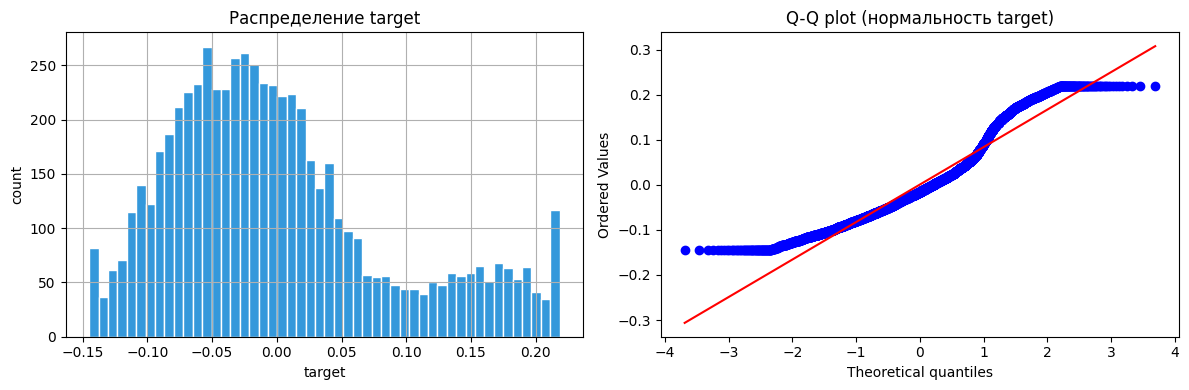

In [25]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')

print(f'\nMissing values (>0%):')
miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
display(miss[miss > 0].rename('missing, %').to_frame())

print(f'\nTarget stats:')
display(df[TARGET].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET].hist(bins=50, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Распределение target')
axes[0].set_xlabel('target')
axes[0].set_ylabel('count')

stats.probplot(df[TARGET].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot (нормальность target)')
plt.tight_layout()
plt.show()

## 3. Группы признаков

In [26]:
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
    'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m',
    'nearest_subway_dist_m', 'nearest_post_offices_dist_m',
    'nearest_offices_dist_m', 'nearest_shops_food_small_dist_m',
    'nearest_fitness_sport_dist_m', 'nearest_hotels_hostels_dist_m',
    'land_use_dist_m', 'city_center_dist_m', 'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m', 'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = [
    'federal_district', 'city_size_category', 'land_use_type', 'atm_group',
]

ALL_FEATURES = BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f'Binary:     {len([f for f in BINARY_FEATURES if f in df.columns])}')
print(f'Distance:   {len([f for f in DISTANCE_FEATURES if f in df.columns])}')
print(f'Count:      {len([f for f in COUNT_FEATURES if f in df.columns])}')
print(f'Economic:   {len([f for f in ECONOMIC_FEATURES if f in df.columns])}')
print(f'Categorical:{len([f for f in CATEGORICAL_FEATURES if f in df.columns])}')
print(f'Total:      {len(ALL_FEATURES)}')

Binary:     17
Distance:   17
Count:      25
Economic:   4
Categorical:4
Total:      67


## 4. Подготовка данных

In [27]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].astype(float)

for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)

for col in CATEGORICAL_FEATURES:
    if col in X.columns:
        X[col] = X[col].astype(str)

strat_col = df['city_size_category'].fillna('unknown') if 'city_size_category' in df.columns else None

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = df.loc[X_trainval.index, 'city_size_category'].fillna('unknown')
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

print(f'Train     : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val       : {X_val.shape}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test      : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'Train target: mean={y_train.mean():.4f}, std={y_train.std():.4f}')
print(f'Test  target: mean={y_test.mean():.4f},  std={y_test.std():.4f}')

Train     : (4339, 67)  (70%)
Val       : (931, 67)  (15%)
Test      : (930, 67)  (15%)
Train target: mean=0.0015, std=0.0862
Test  target: mean=-0.0007,  std=0.0864


## 5. Препроцессинг

In [28]:
bin_cols  = [f for f in BINARY_FEATURES   if f in X.columns]
dist_cols = [f for f in DISTANCE_FEATURES if f in X.columns]
cnt_cols  = [f for f in COUNT_FEATURES    if f in X.columns]
econ_cols = [f for f in ECONOMIC_FEATURES if f in X.columns]
cat_cols  = [f for f in CATEGORICAL_FEATURES if f in X.columns]

log1p_tf = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

dist_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p',   log1p_tf),
    ('scaler',  StandardScaler()),
])

count_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

econ_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('binary',   bin_pipe,   bin_cols),
        ('distance', dist_pipe,  dist_cols),
        ('count',    count_pipe, cnt_cols),
        ('economic', econ_pipe,  econ_cols),
        ('cat',      cat_pipe,   cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

X_check = preprocessor.fit_transform(X_train)
feat_names = preprocessor.get_feature_names_out()
print(f'Transformed shape: {X_check.shape}')
print(f'Feature names sample: {feat_names[:5]}')

Transformed shape: (4339, 67)
Feature names sample: ['binary__is_24_7' 'binary__contactless_tech' 'binary__qr_codes'
 'binary__usd_available' 'binary__eur_available']


## 6. Вспомогательные функции

In [29]:
results = []


def timed_fit(pipe, X, y):
    t0 = time.perf_counter()
    pipe.fit(X, y)
    return pipe, time.perf_counter() - t0


def timed_predict(pipe, X):
    t0 = time.perf_counter()
    y_pred = pipe.predict(X)
    return y_pred, time.perf_counter() - t0


def report_metrics(model_name, pipe, X_train, y_train, X_test, y_test, fit_time):
    y_pred_train, train_pred_time = timed_predict(pipe, X_train)
    y_pred_test,  test_pred_time  = timed_predict(pipe, X_test)

    def _m(y_true, y_pred):
        return {
            'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
            'MAE':  round(float(mean_absolute_error(y_true, y_pred)), 4),
            'R²':   round(float(r2_score(y_true, y_pred)), 4),
        }

    train_m = _m(y_train, y_pred_train)
    test_m  = _m(y_test,  y_pred_test)

    table = pd.DataFrame([
        {'Split': 'Train',
         'RMSE': train_m['RMSE'], 'MAE': train_m['MAE'], 'R²': train_m['R²'],
         'Fit time, s':     round(fit_time, 3),
         'Predict time, s': round(train_pred_time, 4)},
        {'Split': 'Test',
         'RMSE': test_m['RMSE'],  'MAE': test_m['MAE'],  'R²': test_m['R²'],
         'Fit time, s':     float('nan'),
         'Predict time, s': round(test_pred_time, 4)},
    ]).set_index('Split')

    print(f'\n{model_name}')
    display(
        table.style
        .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}',
                 'Fit time, s': lambda v: f'{v:.3f}' if not pd.isna(v) else '-',
                 'Predict time, s': '{:.4f}'})
    )

    row = {'Model': model_name,
           'RMSE': test_m['RMSE'], 'MAE': test_m['MAE'], 'R²': test_m['R²'],
           'Fit time, s': round(fit_time, 3),
           'Predict time (test), s': round(test_pred_time, 4)}
    return row, y_pred_test


def kfold_cv(pipe, X, y, n_splits=5):
    scores = cross_val_score(
        pipe, X, y,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE),
        scoring='neg_root_mean_squared_error',
    )
    rmse_scores = -scores
    fold_df = pd.DataFrame({
        'Fold':  [f'Fold {i+1}' for i in range(n_splits)],
        'RMSE':  rmse_scores.round(4),
    }).set_index('Fold').T
    fold_df['Mean'] = rmse_scores.mean().round(4)
    fold_df['Std']  = rmse_scores.std().round(4)
    fold_cols = [f'Fold {i+1}' for i in range(n_splits)]
    display(fold_df.style.format('{:.4f}').apply(
        lambda s: ['font-weight: bold' if v == s[fold_cols].min() else '' for v in s],
        axis=1, subset=fold_cols,
    ))
    return rmse_scores


def log_feature_importance(pipe, title, run, artifact_name='feature_importance.png', top_n=20):
    coef  = pipe.named_steps['model'].coef_
    names = pipe.named_steps['prep'].get_feature_names_out()
    clean = [n.split('__', 1)[-1] for n in names]
    importance = pd.Series(np.abs(coef), index=clean).sort_values(ascending=False)
    sign = pd.Series(coef, index=clean)
    top = importance.head(top_n)
    colors = ['#e74c3c' if sign[f] < 0 else '#3498db' for f in top.index]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax.set_xlabel('|Коэффициент|')
    ax.set_title(f'{title} - Top-{top_n} признаков')
    pos_patch = mpatches.Patch(color='#3498db', label='положительный')
    neg_patch = mpatches.Patch(color='#e74c3c', label='отрицательный')
    ax.legend(handles=[pos_patch, neg_patch])
    plt.tight_layout()
    mlflow.log_figure(fig, artifact_name)
    plt.show(); plt.close(fig)
    nz = np.count_nonzero(coef)
    print(f'Ненулевых коэффициентов: {nz} / {len(coef)} ({100*nz/len(coef):.1f}%)')
    return importance


def log_actual_vs_pred(y_true, y_pred, title, artifact_name='actual_vs_predicted.png'):
    fig, ax = plt.subplots(figsize=(7, 6))
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.scatter(y_true, y_pred, alpha=0.4, s=15)
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='ideal')
    ax.set_xlabel('Факт'); ax.set_ylabel('Предсказания')
    ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    mlflow.log_figure(fig, artifact_name)
    plt.show(); plt.close(fig)


print('Функции определены')


Функции определены


## 7. LinearRegression (baseline)

Fit time: 0.025s

LinearRegression


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0563,0.0440,0.5730,0.025,0.0068
Test,0.0596,0.0472,0.5235,-,0.0039


KFold CV (5 splits)


Fold,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
RMSE,0.0564,0.0566,0.0585,0.0579,0.0572,0.0573,0.0008


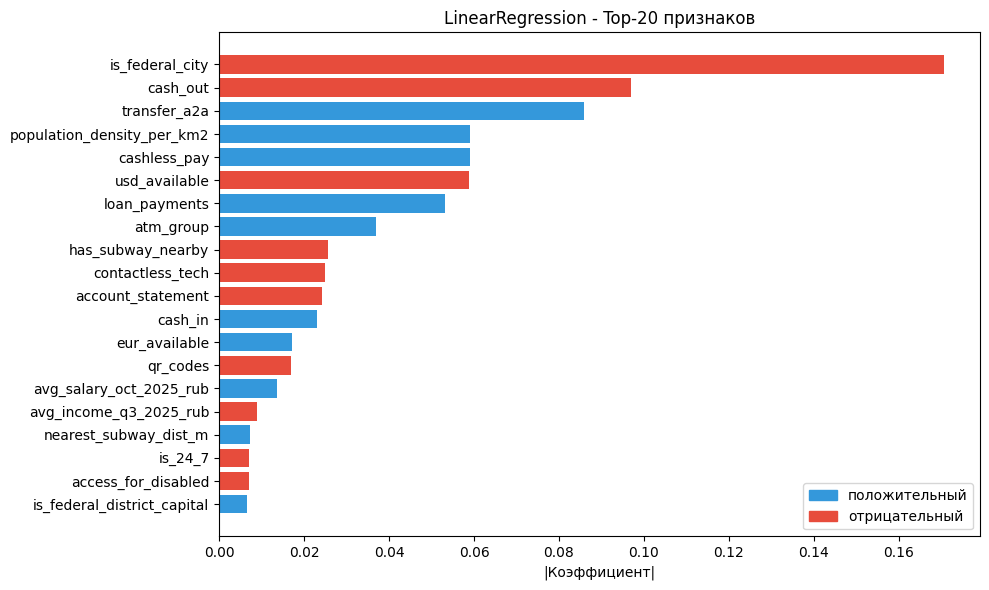

Ненулевых коэффициентов: 67 / 67 (100.0%)


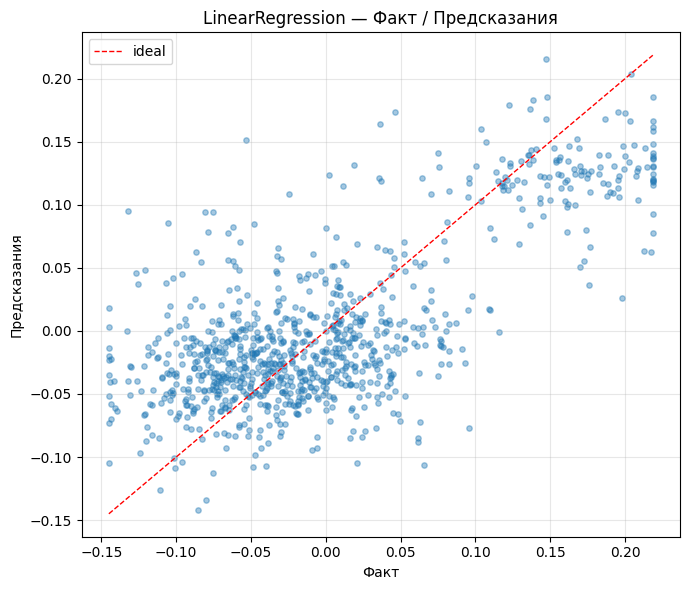

2026/06/02 17:57:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR run_id=92313f9958b244dd9f0e988c0a086d3f
🏃 View run baseline_LR at: http://localhost:5050/#/experiments/2/runs/92313f9958b244dd9f0e988c0a086d3f
🧪 View experiment at: http://localhost:5050/#/experiments/2


In [30]:
with mlflow.start_run(run_name='baseline_LR') as run_lr:
    mlflow.set_tag('model_type', 'LinearRegression')
    mlflow.set_tag('stage', 'baseline')

    lr_pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', LinearRegression()),
    ])
    lr_pipe, lr_fit_time = timed_fit(lr_pipe, X_train, y_train)
    print(f'Fit time: {lr_fit_time:.3f}s')

    row_lr, y_pred_lr_test = report_metrics(
        'LinearRegression', lr_pipe,
        X_train, y_train, X_test, y_test,
        lr_fit_time,
    )
    results.append(row_lr)

    print('KFold CV (5 splits)')
    lr_cv_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
    lr_cv_scores = kfold_cv(lr_cv_pipe, X_train, y_train)

    y_pred_lr_train = lr_pipe.predict(X_train)
    y_pred_lr_val   = lr_pipe.predict(X_val)

    mlflow.log_params({
        'model_type':         'LinearRegression',
        'n_features':         len(ALL_FEATURES),
        'train_size':         len(X_train),
        'val_size':           len(X_val),
        'test_size':          len(X_test),
        'imputer_bin':        'most_frequent',
        'imputer_num':        'median',
        'distance_transform': 'log1p (pipeline)',
        'scaler':             'StandardScaler',
        'data_source':        'train_data_v2.csv',
    })
    mlflow.log_metrics({
        'train_RMSE':   float(np.sqrt(mean_squared_error(y_train, y_pred_lr_train))),
        'val_RMSE':     float(np.sqrt(mean_squared_error(y_val,   y_pred_lr_val))),
        'test_RMSE':    float(row_lr['RMSE']),
        'train_MAE':    float(mean_absolute_error(y_train, y_pred_lr_train)),
        'val_MAE':      float(mean_absolute_error(y_val,   y_pred_lr_val)),
        'test_MAE':     float(row_lr['MAE']),
        'train_R2':     float(r2_score(y_train, y_pred_lr_train)),
        'val_R2':       float(r2_score(y_val,   y_pred_lr_val)),
        'test_R2':      float(row_lr['R²']),
        'fit_time_s':   lr_fit_time,
        'cv_mean_rmse': float(lr_cv_scores.mean()),
        'cv_std_rmse':  float(lr_cv_scores.std()),
    })

    imp_lr = log_feature_importance(lr_pipe, 'LinearRegression', run_lr)
    log_actual_vs_pred(y_test, y_pred_lr_test, 'LinearRegression — Факт / Предсказания')

    mlflow.sklearn.log_model(lr_pipe, name='model')
    LR_RUN_ID = run_lr.info.run_id
    print(f'LR run_id={LR_RUN_ID}')


- RMSE = **0.0596**, R² = **0.5235**
- Gap train/test = +0.0034 → сильного переобучения нет
- Топ-3: `is_federal_city`, `cash_out`, `transfer_a2a`
- Модель объясняет около **52%** дисперсии таргета


## 8. Ridge

In [31]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

ridge_cv_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RidgeCV(alphas=alphas, cv=5)),
])
ridge_cv_pipe.fit(X_train, y_train)
best_alpha_ridge = ridge_cv_pipe.named_steps['model'].alpha_
print(f'Лучший alpha: {best_alpha_ridge}')

with mlflow.start_run(run_name='hp_search_Ridge'):
    mlflow.set_tag('model_type', 'Ridge')
    mlflow.set_tag('stage', 'hp_search')
    mlflow.log_param('alphas_tested', str(alphas))
    mlflow.log_param('best_alpha', best_alpha_ridge)
    mlflow.log_param('cv_folds', 5)
    print(f'hp_search_Ridge logged, best_alpha={best_alpha_ridge}')


Лучший alpha: 0.1
hp_search_Ridge logged, best_alpha=0.1
🏃 View run hp_search_Ridge at: http://localhost:5050/#/experiments/2/runs/9d70621848724b699a63cf45ec90a173
🧪 View experiment at: http://localhost:5050/#/experiments/2


Fit time: 0.022s

Ridge (alpha=0.1)


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0563,0.0440,0.5730,0.022,0.0074
Test,0.0596,0.0472,0.5235,-,0.0052


KFold CV (5 splits)


Fold,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
RMSE,0.0564,0.0567,0.0584,0.0579,0.0571,0.0573,0.0008


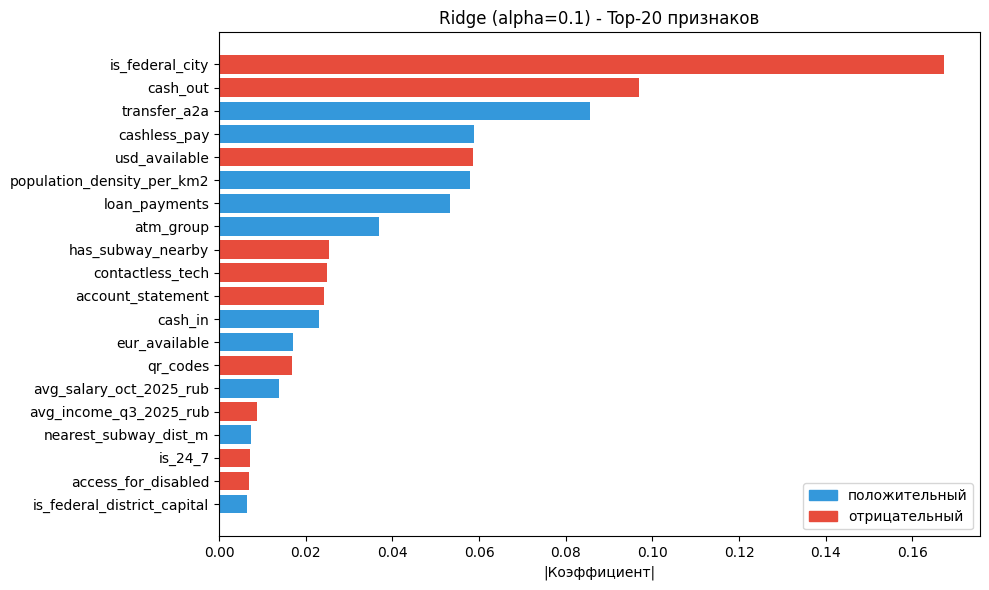

Ненулевых коэффициентов: 66 / 67 (98.5%)


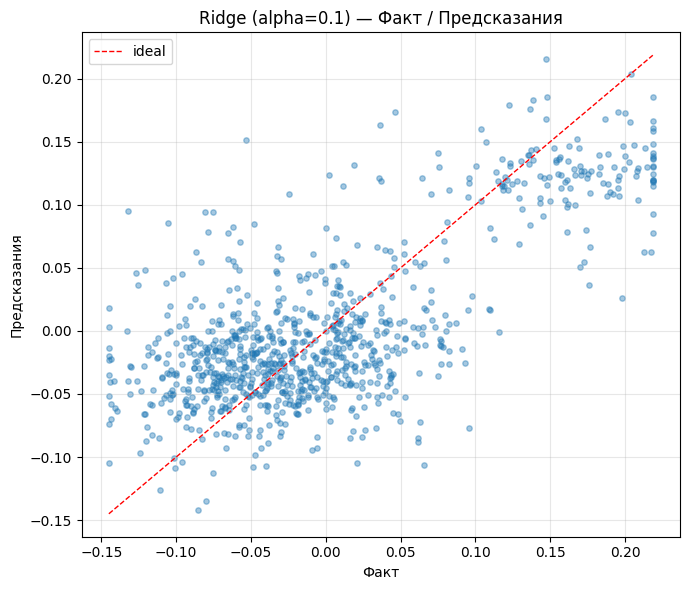

2026/06/02 17:57:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge run_id=ecb41267105d47468bf280aceb809eca
🏃 View run baseline_Ridge at: http://localhost:5050/#/experiments/2/runs/ecb41267105d47468bf280aceb809eca
🧪 View experiment at: http://localhost:5050/#/experiments/2


In [32]:
with mlflow.start_run(run_name='baseline_Ridge') as run_ridge:
    mlflow.set_tag('model_type', 'Ridge')
    mlflow.set_tag('stage', 'baseline')

    ridge_pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', Ridge(alpha=best_alpha_ridge)),
    ])
    ridge_pipe, ridge_fit_time = timed_fit(ridge_pipe, X_train, y_train)
    print(f'Fit time: {ridge_fit_time:.3f}s')

    row_ridge, y_pred_ridge_test = report_metrics(
        f'Ridge (alpha={best_alpha_ridge})', ridge_pipe,
        X_train, y_train, X_test, y_test,
        ridge_fit_time,
    )
    results.append(row_ridge)

    print('KFold CV (5 splits)')
    ridge_cv2_pipe = Pipeline([('prep', preprocessor), ('model', Ridge(alpha=best_alpha_ridge))])
    ridge_cv_scores = kfold_cv(ridge_cv2_pipe, X_train, y_train)

    y_pred_ridge_train = ridge_pipe.predict(X_train)
    y_pred_ridge_val   = ridge_pipe.predict(X_val)

    mlflow.log_params({
        'model_type':         'Ridge',
        'alpha':              best_alpha_ridge,
        'n_features':         len(ALL_FEATURES),
        'train_size':         len(X_train),
        'val_size':           len(X_val),
        'test_size':          len(X_test),
        'imputer_bin':        'most_frequent',
        'imputer_num':        'median',
        'distance_transform': 'log1p (pipeline)',
        'scaler':             'StandardScaler',
        'data_source':        'train_data_v2.csv',
    })
    mlflow.log_metrics({
        'train_RMSE':   float(np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))),
        'val_RMSE':     float(np.sqrt(mean_squared_error(y_val,   y_pred_ridge_val))),
        'test_RMSE':    float(row_ridge['RMSE']),
        'train_MAE':    float(mean_absolute_error(y_train, y_pred_ridge_train)),
        'val_MAE':      float(mean_absolute_error(y_val,   y_pred_ridge_val)),
        'test_MAE':     float(row_ridge['MAE']),
        'train_R2':     float(r2_score(y_train, y_pred_ridge_train)),
        'val_R2':       float(r2_score(y_val,   y_pred_ridge_val)),
        'test_R2':      float(row_ridge['R²']),
        'fit_time_s':   ridge_fit_time,
        'cv_mean_rmse': float(ridge_cv_scores.mean()),
        'cv_std_rmse':  float(ridge_cv_scores.std()),
    })

    imp_ridge = log_feature_importance(ridge_pipe, f'Ridge (alpha={best_alpha_ridge})', run_ridge)
    log_actual_vs_pred(y_test, y_pred_ridge_test, f'Ridge (alpha={best_alpha_ridge}) — Факт / Предсказания')

    mlflow.sklearn.log_model(ridge_pipe, name='model')
    RIDGE_RUN_ID = run_ridge.info.run_id
    print(f'Ridge run_id={RIDGE_RUN_ID}')


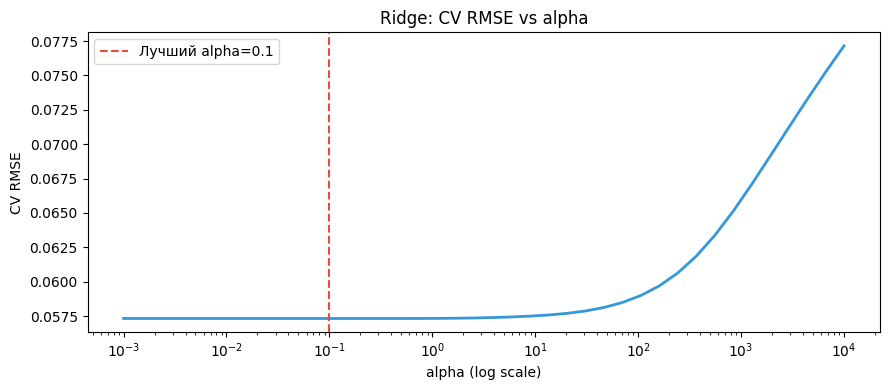

In [33]:
alphas_grid = np.logspace(-3, 4, 40)
alpha_rmse = []
for a in alphas_grid:
    p = Pipeline([('prep', preprocessor), ('model', Ridge(alpha=a))])
    s = cross_val_score(p, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    alpha_rmse.append(-s.mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas_grid, alpha_rmse, color='#3498db', linewidth=2)
ax.axvline(best_alpha_ridge, color='#e74c3c', linestyle='--',
           label=f'Лучший alpha={best_alpha_ridge}')
ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('CV RMSE')
ax.set_title('Ridge: CV RMSE vs alpha')
ax.legend()
plt.tight_layout()
plt.show()


- Лучший alpha = **0.1** — слабая регуляризация
- RMSE ≈ LR: Ridge почти не меняет качество относительно baseline
- Вывод: при текущем наборе признаков L2-регуляризация не даёт заметного прироста


## 9. Lasso

In [34]:
lasso_param_grid = {
    'model__alpha': np.logspace(-5, 2, 30),
    'model__tol':   [1e-3, 1e-4],
}

lasso_search_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Lasso(max_iter=200_000, random_state=RANDOM_STATE)),
])

gs_lasso = GridSearchCV(
    lasso_search_pipe, lasso_param_grid,
    cv=5, scoring='neg_root_mean_squared_error', verbose=1,
)
gs_lasso.fit(X_train, y_train)

best_alpha_lasso = gs_lasso.best_params_['model__alpha']
best_tol_lasso   = gs_lasso.best_params_['model__tol']
print(f'Лучший alpha: {best_alpha_lasso:.6f}, tol: {best_tol_lasso}')
print(f'Лучший CV RMSE: {-gs_lasso.best_score_:.4f}')

with mlflow.start_run(run_name='hp_search_Lasso'):
    mlflow.set_tag('model_type', 'Lasso')
    mlflow.set_tag('stage', 'hp_search')
    mlflow.log_param('best_alpha', best_alpha_lasso)
    mlflow.log_param('best_tol', best_tol_lasso)
    mlflow.log_metric('best_cv_rmse', -gs_lasso.best_score_)
    print(f'hp_search_Lasso logged, best_alpha={best_alpha_lasso:.6f}')


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Лучший alpha: 0.000010, tol: 0.0001
Лучший CV RMSE: 0.0573
hp_search_Lasso logged, best_alpha=0.000010
🏃 View run hp_search_Lasso at: http://localhost:5050/#/experiments/2/runs/8f799ff7bc894f028e1f8456bd5a2a7a
🧪 View experiment at: http://localhost:5050/#/experiments/2


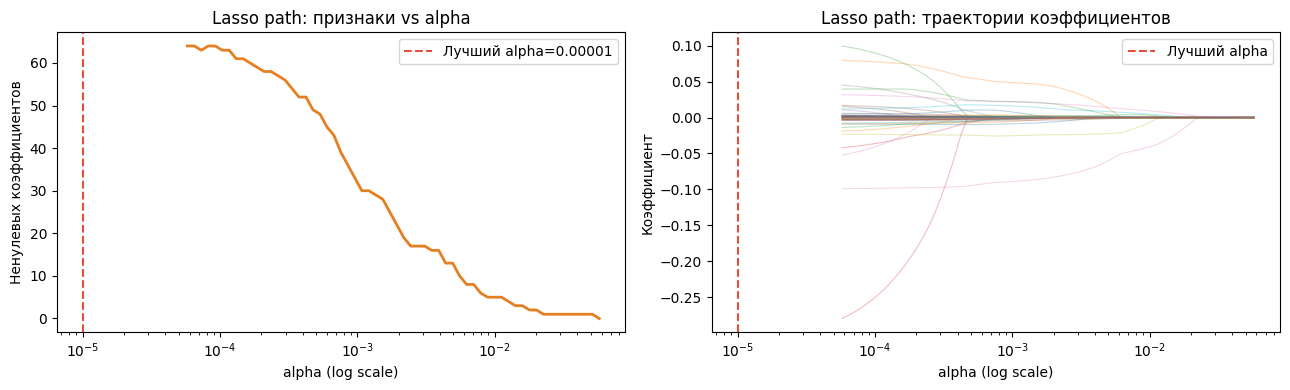

In [35]:
X_train_prep = preprocessor.transform(X_train)
alphas_path, coefs_path, _ = lasso_path(X_train_prep, y_train, n_alphas=60)
n_nonzero = (coefs_path != 0).sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogx(alphas_path, n_nonzero, color='#e67e22', linewidth=2)
axes[0].axvline(best_alpha_lasso, color='#e74c3c', linestyle='--',
                label=f'Лучший alpha={best_alpha_lasso:.5f}')
axes[0].set_xlabel('alpha (log scale)')
axes[0].set_ylabel('Ненулевых коэффициентов')
axes[0].set_title('Lasso path: признаки vs alpha')
axes[0].legend()

axes[1].semilogx(alphas_path, coefs_path.T, alpha=0.3, linewidth=0.8)
axes[1].axvline(best_alpha_lasso, color='#e74c3c', linestyle='--',
                linewidth=1.5, label='Лучший alpha')
axes[1].set_xlabel('alpha (log scale)')
axes[1].set_ylabel('Коэффициент')
axes[1].set_title('Lasso path: траектории коэффициентов')
axes[1].legend()
plt.tight_layout()
plt.show()


Fit time: 0.064s

Lasso (alpha=0.00001)


,RMSE,MAE,R²,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0563,0.0440,0.5729,0.064,0.0080
Test,0.0596,0.0472,0.5236,-,0.0045


KFold CV (5 splits)


Fold,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
RMSE,0.0564,0.0567,0.0584,0.0579,0.0571,0.0573,0.0007


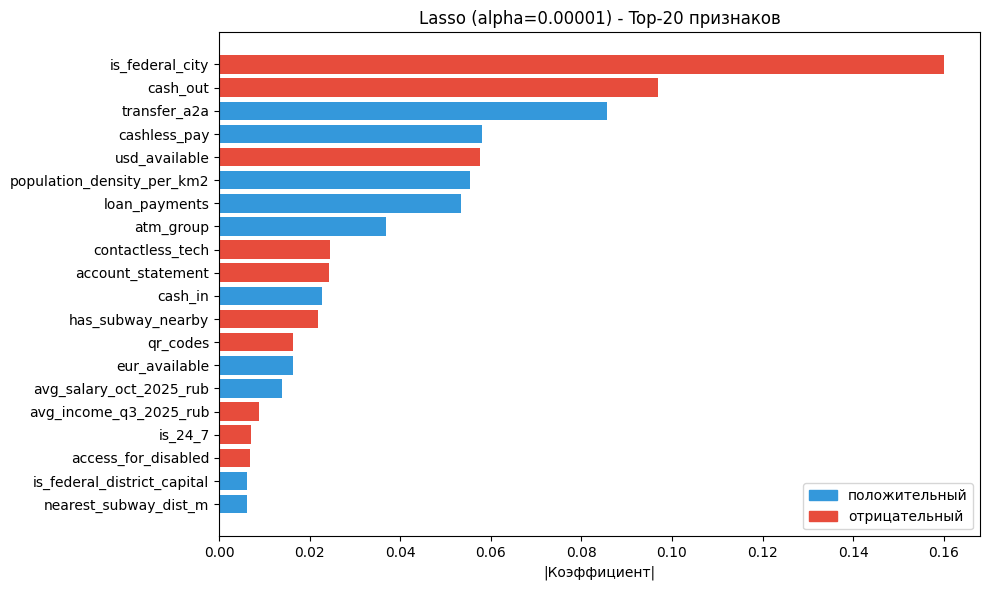

Ненулевых коэффициентов: 66 / 67 (98.5%)


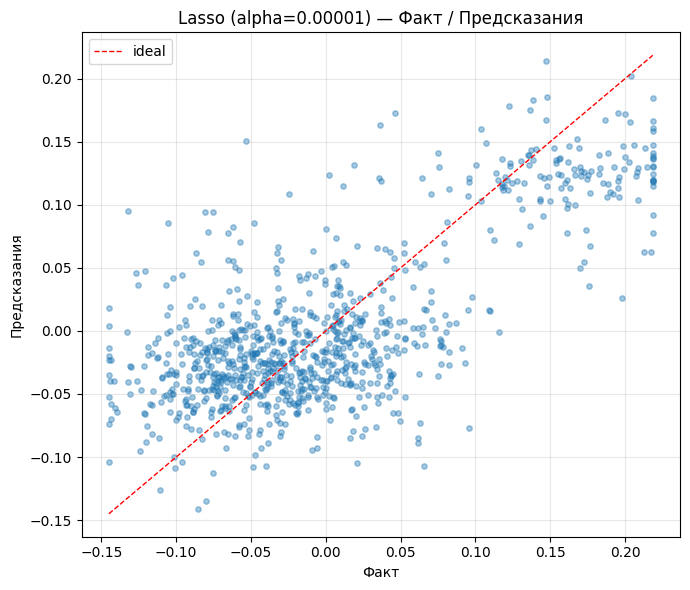

Lasso обнулил: 1 из 67 признаков → осталось 66 (98.5%)


2026/06/02 17:57:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso run_id=698f7aa5b95945cfb1be3a50e08d0de1
🏃 View run baseline_Lasso at: http://localhost:5050/#/experiments/2/runs/698f7aa5b95945cfb1be3a50e08d0de1
🧪 View experiment at: http://localhost:5050/#/experiments/2


In [36]:
with mlflow.start_run(run_name='baseline_Lasso') as run_lasso:
    mlflow.set_tag('model_type', 'Lasso')
    mlflow.set_tag('stage', 'baseline')

    lasso_pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', Lasso(alpha=best_alpha_lasso, tol=best_tol_lasso,
                        max_iter=200_000, random_state=RANDOM_STATE)),
    ])
    lasso_pipe, lasso_fit_time = timed_fit(lasso_pipe, X_train, y_train)
    print(f'Fit time: {lasso_fit_time:.3f}s')

    row_lasso, y_pred_lasso_test = report_metrics(
        f'Lasso (alpha={best_alpha_lasso:.5f})', lasso_pipe,
        X_train, y_train, X_test, y_test,
        lasso_fit_time,
    )
    results.append(row_lasso)

    print('KFold CV (5 splits)')
    lasso_cv_pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', Lasso(alpha=best_alpha_lasso, tol=best_tol_lasso,
                        max_iter=200_000, random_state=RANDOM_STATE)),
    ])
    lasso_cv_scores = kfold_cv(lasso_cv_pipe, X_train, y_train)

    y_pred_lasso_train = lasso_pipe.predict(X_train)
    y_pred_lasso_val   = lasso_pipe.predict(X_val)

    mlflow.log_params({
        'model_type':         'Lasso',
        'alpha':              best_alpha_lasso,
        'tol':                best_tol_lasso,
        'max_iter':           200_000,
        'n_features':         len(ALL_FEATURES),
        'train_size':         len(X_train),
        'val_size':           len(X_val),
        'test_size':          len(X_test),
        'imputer_bin':        'most_frequent',
        'imputer_num':        'median',
        'distance_transform': 'log1p (pipeline)',
        'scaler':             'StandardScaler',
        'data_source':        'train_data_v2.csv',
    })
    mlflow.log_metrics({
        'train_RMSE':   float(np.sqrt(mean_squared_error(y_train, y_pred_lasso_train))),
        'val_RMSE':     float(np.sqrt(mean_squared_error(y_val,   y_pred_lasso_val))),
        'test_RMSE':    float(row_lasso['RMSE']),
        'train_MAE':    float(mean_absolute_error(y_train, y_pred_lasso_train)),
        'val_MAE':      float(mean_absolute_error(y_val,   y_pred_lasso_val)),
        'test_MAE':     float(row_lasso['MAE']),
        'train_R2':     float(r2_score(y_train, y_pred_lasso_train)),
        'val_R2':       float(r2_score(y_val,   y_pred_lasso_val)),
        'test_R2':      float(row_lasso['R²']),
        'fit_time_s':   lasso_fit_time,
        'cv_mean_rmse': float(lasso_cv_scores.mean()),
        'cv_std_rmse':  float(lasso_cv_scores.std()),
    })

    imp_lasso = log_feature_importance(lasso_pipe, f'Lasso (alpha={best_alpha_lasso:.5f})', run_lasso)
    log_actual_vs_pred(y_test, y_pred_lasso_test, f'Lasso (alpha={best_alpha_lasso:.5f}) — Факт / Предсказания')

    coef_lasso = lasso_pipe.named_steps['model'].coef_
    nz = np.count_nonzero(coef_lasso)
    total = len(coef_lasso)
    print(f'Lasso обнулил: {total - nz} из {total} признаков → осталось {nz} ({100*nz/total:.1f}%)')

    mlflow.sklearn.log_model(lasso_pipe, name='model')
    LASSO_RUN_ID = run_lasso.info.run_id
    print(f'Lasso run_id={LASSO_RUN_ID}')


- alpha = 0.00001: почти OLS — регуляризация минимальна
- RMSE ≈ Ridge/LR: качество практически то же
- Lasso полезен как проверка избыточности, но не как компактная финальная модель


## 10. Сравнительная таблица


In [37]:
results_df = pd.DataFrame(results).set_index('Model')
comparison = results_df.sort_values('RMSE')

def bold_min(s):
    return ['font-weight: bold' if v == s.min() else '' for v in s]

def bold_max(s):
    return ['font-weight: bold' if v == s.max() else '' for v in s]

display(
    comparison.style
    .apply(bold_min, subset=['RMSE', 'MAE'])
    .apply(bold_max, subset=['R\u00b2'])
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R\u00b2': '{:.4f}',
             'Fit time, s': lambda v: f'{v:.3f}' if pd.notna(v) else '-',
             'Predict time (test), s': lambda v: f'{v:.4f}' if pd.notna(v) else '-'}, na_rep='-')
)

best_model_name = comparison['RMSE'].idxmin()
print(f'\u041b\u0443\u0447\u0448\u0430\u044f \u0431\u0430\u0437\u043e\u0432\u0430\u044f \u043b\u0438\u043d\u0435\u0439\u043d\u0430\u044f \u043c\u043e\u0434\u0435\u043b\u044c: {best_model_name}')

model_map = {
    'LinearRegression':                      lr_pipe,
    f'Ridge (alpha={best_alpha_ridge})':     ridge_pipe,
    f'Lasso (alpha={best_alpha_lasso:.5f})': lasso_pipe,
}

best_pipe = model_map.get(best_model_name, list(model_map.values())[0])

save_path = MODELS_DIR / 'linear_model_best.pkl'
joblib.dump(best_pipe, save_path)
print(f'\u0421\u043e\u0445\u0440\u0430\u043d\u0435\u043d\u043e: {save_path}  ({save_path.stat().st_size / 1024:.1f} KB)')

,RMSE,MAE,R²,"Fit time, s","Predict time (test), s"
Model,,,,,
LinearRegression,0.0596,0.0472,0.5235,0.025,0.0039
Ridge (alpha=0.1),0.0596,0.0472,0.5235,0.022,0.0052
Lasso (alpha=0.00001),0.0596,0.0472,0.5236,0.064,0.0045


Лучшая базовая линейная модель: LinearRegression
Сохранено: ..\models\linear_model_best.pkl  (13.9 KB)


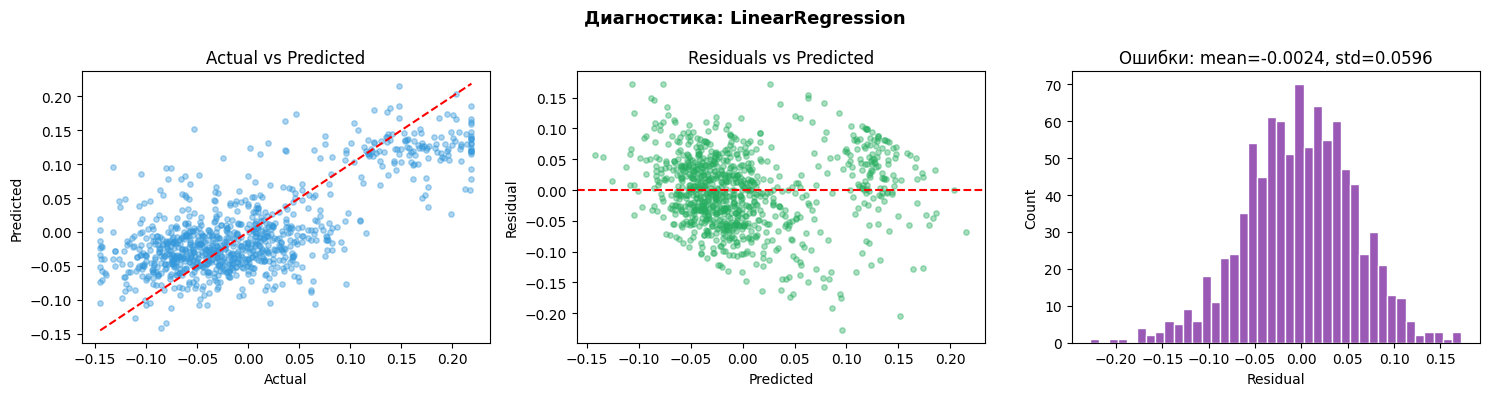

In [38]:
y_pred_best = best_pipe.predict(X_test)
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_test, y_pred_best, alpha=0.4, s=15, color='#3498db')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=15, color='#27ae60')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=40, color='#9b59b6', edgecolor='white')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'\u041e\u0448\u0438\u0431\u043a\u0438: mean={residuals.mean():.4f}, std={residuals.std():.4f}')

plt.suptitle(f'\u0414\u0438\u0430\u0433\u043d\u043e\u0441\u0442\u0438\u043a\u0430: {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
kfold_summary = pd.DataFrame({
    'LinearRegression':                  lr_cv_scores.round(4),
    f'Ridge (a={best_alpha_ridge})':     ridge_cv_scores.round(4),
    f'Lasso (a={best_alpha_lasso:.5f})': lasso_cv_scores.round(4),
}, index=[f'Fold {i+1}' for i in range(5)]).T
kfold_summary['Mean'] = kfold_summary.mean(axis=1).round(4)
kfold_summary['Std']  = kfold_summary.std(axis=1).round(4)

fold_cols = [f'Fold {i+1}' for i in range(5)]
display(
    kfold_summary.style.format('{:.4f}')
    .apply(lambda s: ['font-weight: bold' if v == s[fold_cols].min() else '' for v in s],
           axis=1, subset=fold_cols)
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s],
           axis=0, subset=['Mean'])
)

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
LinearRegression,0.0564,0.0566,0.0585,0.0579,0.0572,0.0573,0.0008
Ridge (a=0.1),0.0564,0.0567,0.0584,0.0579,0.0571,0.0573,0.0007
Lasso (a=0.00001),0.0564,0.0567,0.0584,0.0579,0.0571,0.0573,0.0007


## 11. Сравнение важностей признаков

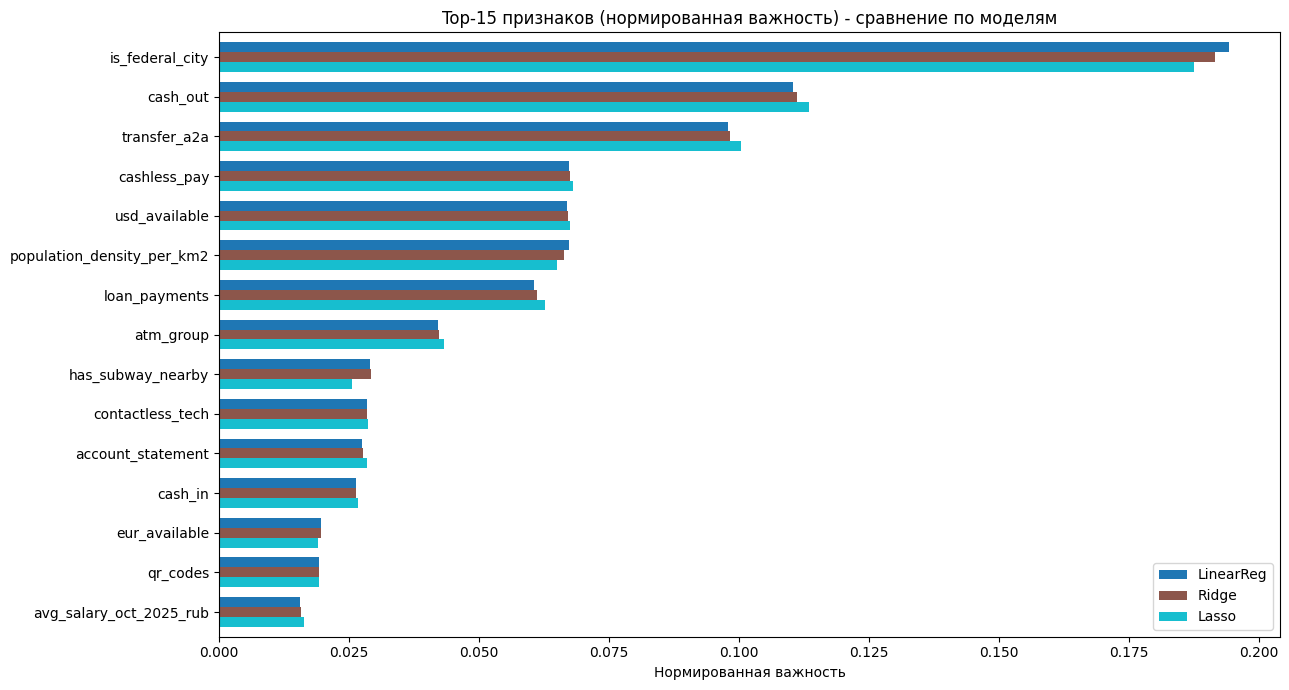

In [44]:
def get_norm_importance(pipe):
    names = pipe.named_steps['prep'].get_feature_names_out()
    vals  = np.abs(pipe.named_steps['model'].coef_)
    clean = [n.split('__', 1)[-1] for n in names]
    s = pd.Series(vals, index=clean)
    return s / s.sum()


imp_lr_n    = get_norm_importance(lr_pipe)
imp_ridge_n = get_norm_importance(ridge_pipe)
imp_lasso_n = get_norm_importance(lasso_pipe)

top15 = imp_ridge_n.sort_values(ascending=False).head(15).index

imp_compare = pd.DataFrame({
    'LinearReg': imp_lr_n.reindex(top15),
    'Ridge':     imp_ridge_n.reindex(top15),
    'Lasso':     imp_lasso_n.reindex(top15),
}).fillna(0)

fig, ax = plt.subplots(figsize=(13, 7))
imp_compare.plot(kind='barh', ax=ax, colormap='tab10', width=0.75)
ax.set_title('Top-15 \u043f\u0440\u0438\u0437\u043d\u0430\u043a\u043e\u0432 (\u043d\u043e\u0440\u043c\u0438\u0440\u043e\u0432\u0430\u043d\u043d\u0430\u044f \u0432\u0430\u0436\u043d\u043e\u0441\u0442\u044c) - \u0441\u0440\u0430\u0432\u043d\u0435\u043d\u0438\u0435 \u043f\u043e \u043c\u043e\u0434\u0435\u043b\u044f\u043c')
ax.set_xlabel('\u041d\u043e\u0440\u043c\u0438\u0440\u043e\u0432\u0430\u043d\u043d\u0430\u044f \u0432\u0430\u0436\u043d\u043e\u0441\u0442\u044c')
ax.invert_yaxis()
plt.tight_layout()
plt.show()